# 04: Exploratory Data Analysis

This notebook explores the cleaned UNSW-NB15 dataset to develop an understanding of the data's structure before any modelling takes place. The analyses performed here directly inform the feature engineering decisions in notebook 05.

The sections cover class distributions (to quantify imbalance between normal and attack traffic and across attack categories), cardinality analysis (to guide encoding strategy for categorical features), feature distributions (to identify skew and candidate features for log transformation), correlation analysis using Kendall tau (to identify weak predictors and redundant feature pairs), and outlier detection (to understand which features carry extreme values and whether those extremes correspond to attack behaviour).

## 4.1: Import Libraries

This section imports all libraries required by the notebook and configures global display settings. Libraries are grouped by purpose: data manipulation (NumPy, pandas) and visualisation (matplotlib, seaborn). The display option prevents pandas from truncating long column values, and the seaborn style is set to a white grid to ensure all plots in this notebook are consistently styled.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Prevent truncation of long column values in displayed DataFrames
pd.set_option('display.max_colwidth', None)

# Set a white grid background for all plots
sns.set_style('whitegrid')

## 4.2: Load Dataset

This section loads the cleaned dataset produced by notebook 03 from `data/cleaned/UNSW-NB15.csv`. The first five rows are displayed to confirm the file has loaded correctly and that column names are present before any analysis begins.

In [2]:
# Load the cleaned dataset
df = pd.read_csv('../data/cleaned/UNSW-NB15.csv', low_memory=False)

In [3]:
# Display the first five rows to confirm the dataset loaded correctly with column names.
df.head()

,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,udp,CON,0.001055,132,164,31,29,0,0,dns,...,0.0,3,7,1,3,1,1,1,Normal,0
1,udp,CON,0.036133,528,304,31,29,0,0,unidentified,...,0.0,2,4,2,3,1,1,2,Normal,0
2,udp,CON,0.001119,146,178,31,29,0,0,dns,...,0.0,12,8,1,2,2,1,1,Normal,0
3,udp,CON,0.001209,132,164,31,29,0,0,dns,...,0.0,6,9,1,1,1,1,1,Normal,0
4,udp,CON,0.001169,146,178,31,29,0,0,dns,...,0.0,7,9,1,1,1,1,1,Normal,0


## 4.3: Class Distributions

Class distribution analysis reveals how balanced the dataset is between normal and attack traffic. An imbalanced dataset — where one class far outnumbers another — can cause a model to be biased toward the majority class, leading to poor detection of attacks. Understanding the distribution early on helps inform decisions around resampling strategies, class weighting, or threshold tuning during modelling.

### 4.3.1: Normal vs Attack Traffic

This subsection quantifies the binary class imbalance between normal and attack records. Understanding the degree of imbalance is critical before modelling — a heavily skewed dataset will require an explicit resampling or weighting strategy to prevent the classifier from simply predicting the majority class. A pie chart shows the proportional split and a bar chart shows the absolute counts.

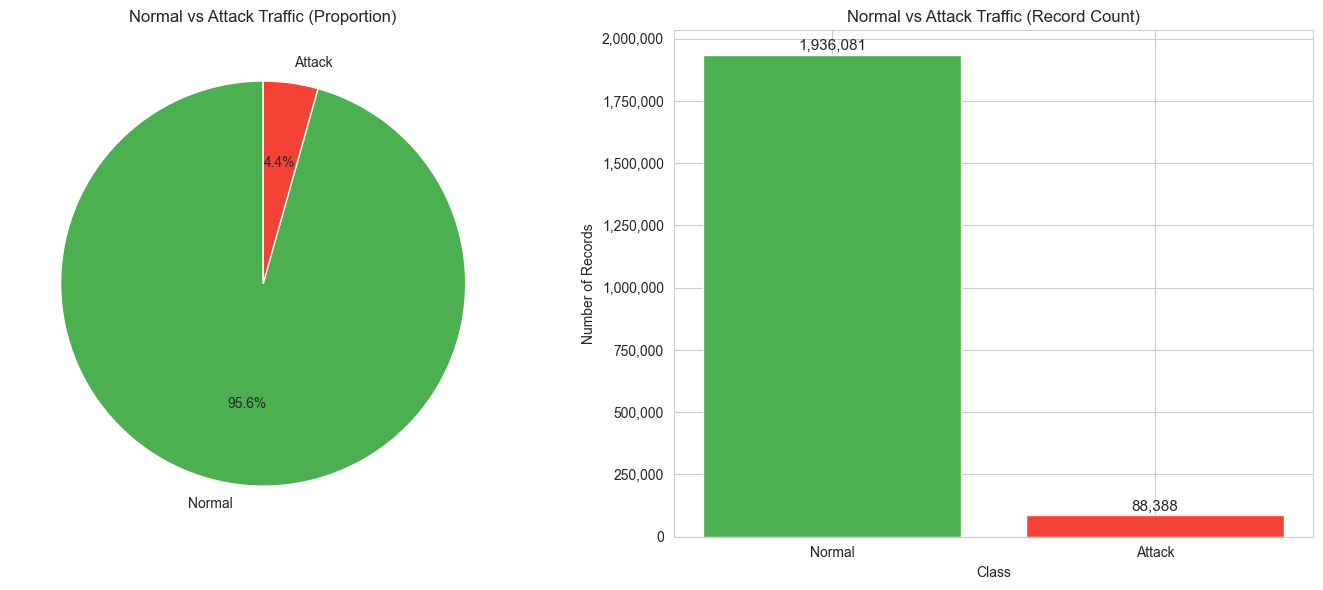

In [4]:
# Count records per class
label_counts = df['Label'].value_counts()
label_names = ['Normal', 'Attack']

fig, (ax_pie, ax_bar) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart: proportion of normal vs attack traffic
ax_pie.pie(
    label_counts,
    labels=label_names,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4CAF50', '#F44336']
)
ax_pie.set_title('Normal vs Attack Traffic (Proportion)')

# Bar chart: absolute record count per class
bars = ax_bar.bar(label_names, label_counts.values, color=['#4CAF50', '#F44336'])
ax_bar.set_title('Normal vs Attack Traffic (Record Count)')
ax_bar.set_xlabel('Class')
ax_bar.set_ylabel('Number of Records')

# Format y-axis ticks as integers with commas (no scientific notation)
ax_bar.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Annotate each bar with its exact count
for bar, count in zip(bars, label_counts.values):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5000,
        f'{count:,}',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()

### 4.3.2: Attack Categories

Breaking down attack traffic into its specific categories reveals which attack types are most and least represented. Rare categories such as Worms or Backdoor may be harder for a model to learn from due to limited examples, which may warrant oversampling or targeted evaluation.

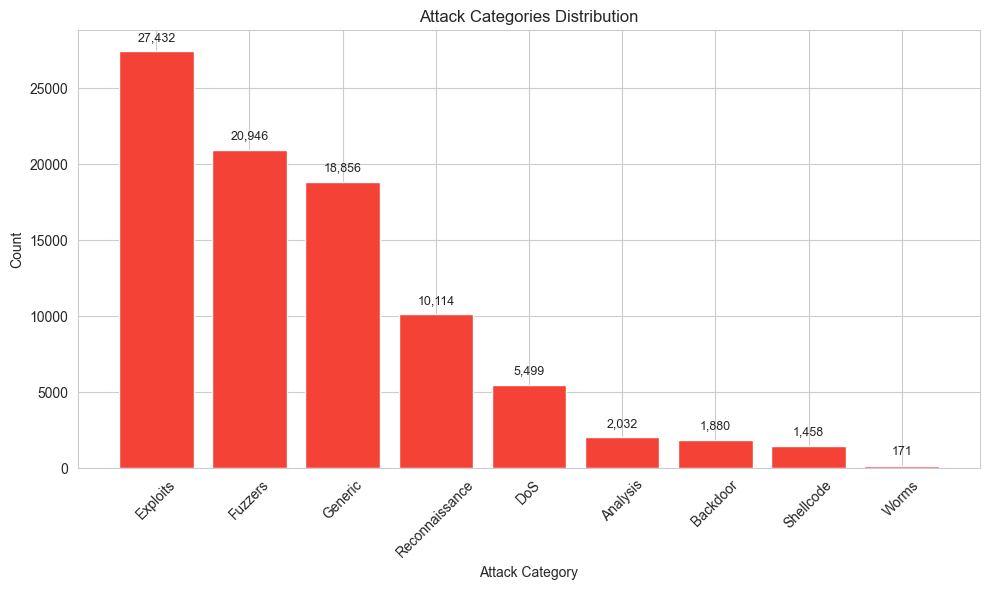

In [5]:
# Count the frequency of each attack category (excluding Normal traffic)
attack_counts = df[df['attack_cat'] != 'Normal']['attack_cat'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))

# Bar chart: distribution of attack types
ax.bar(attack_counts.index, attack_counts.values, color='#F44336')
ax.set_title('Attack Categories Distribution')
ax.set_xlabel('Attack Category')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

# Annotate each bar with its count
for index, (category, count) in enumerate(zip(attack_counts.index, attack_counts.values)):
    ax.text(index, count + 500, f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 4.4: Cardinality Analysis

Cardinality is the number of unique values a feature takes. It informs how a feature should be encoded and whether it carries meaningful variation. Binary features (cardinality = 2) are already suitable for direct model input. Low-cardinality features with a small number of discrete values are candidates for one-hot encoding. High-cardinality features may need target encoding, hashing, or grouping of rare categories to avoid dimensionality explosion. Features with cardinality equal to the number of rows are effectively identifiers and should be dropped.

In [6]:
# Count unique values per feature and express as a percentage of total records
total_records = len(df)
unique_counts = df.drop(columns=['Label', 'attack_cat']).nunique()
unique_percentage = (unique_counts / total_records * 100).round(2)

# Classify each feature's cardinality to guide encoding decisions in 05_feature_engineering
def classify_cardinality(count):
    if count == 2:
        return 'Binary'
    elif count <= 20:
        return 'Low'
    elif count <= 100:
        return 'Medium'
    else:
        return 'High'

cardinality_summary = pd.DataFrame({
    'Unique Values': unique_counts,
    'Unique %': unique_percentage,
    'Type': df.drop(columns=['Label', 'attack_cat']).dtypes,
    'Cardinality Class': unique_counts.map(classify_cardinality)
}).sort_values('Unique Values', ascending=False)

display(cardinality_summary)

,Unique Values,Unique %,Type,Cardinality Class
Djit,1424109,70.34,float64,High
Sjit,1379743,68.15,float64,High
Dload,1172996,57.94,float64,High
Sload,1099426,54.31,float64,High
Sintpkt,974280,48.13,float64,High
Dintpkt,959621,47.40,float64,High
dur,587302,29.01,float64,High
synack,66997,3.31,float64,High
ackdat,60844,3.01,float64,High
dbytes,19104,0.94,int64,High


## 4.5: Feature Distribution

Feature distribution analysis shows how the values of each numeric feature are spread across the dataset. Highly skewed distributions, heavy tails, or multimodal patterns can indicate the presence of attack behaviour, noisy measurements, or features that may benefit from log transformation or normalisation before modelling.

In [7]:
# Select numeric features, excluding the binary Label column
numeric_columns = df.select_dtypes(include=[np.number]).columns.drop('Label').tolist()
print(f'Numeric features: {len(numeric_columns)}')
print(numeric_columns)

Numeric features: 35
['dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'Sload', 'Dload', 'Spkts', 'Dpkts', 'swin', 'dwin', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'Sjit', 'Djit', 'Sintpkt', 'Dintpkt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm']


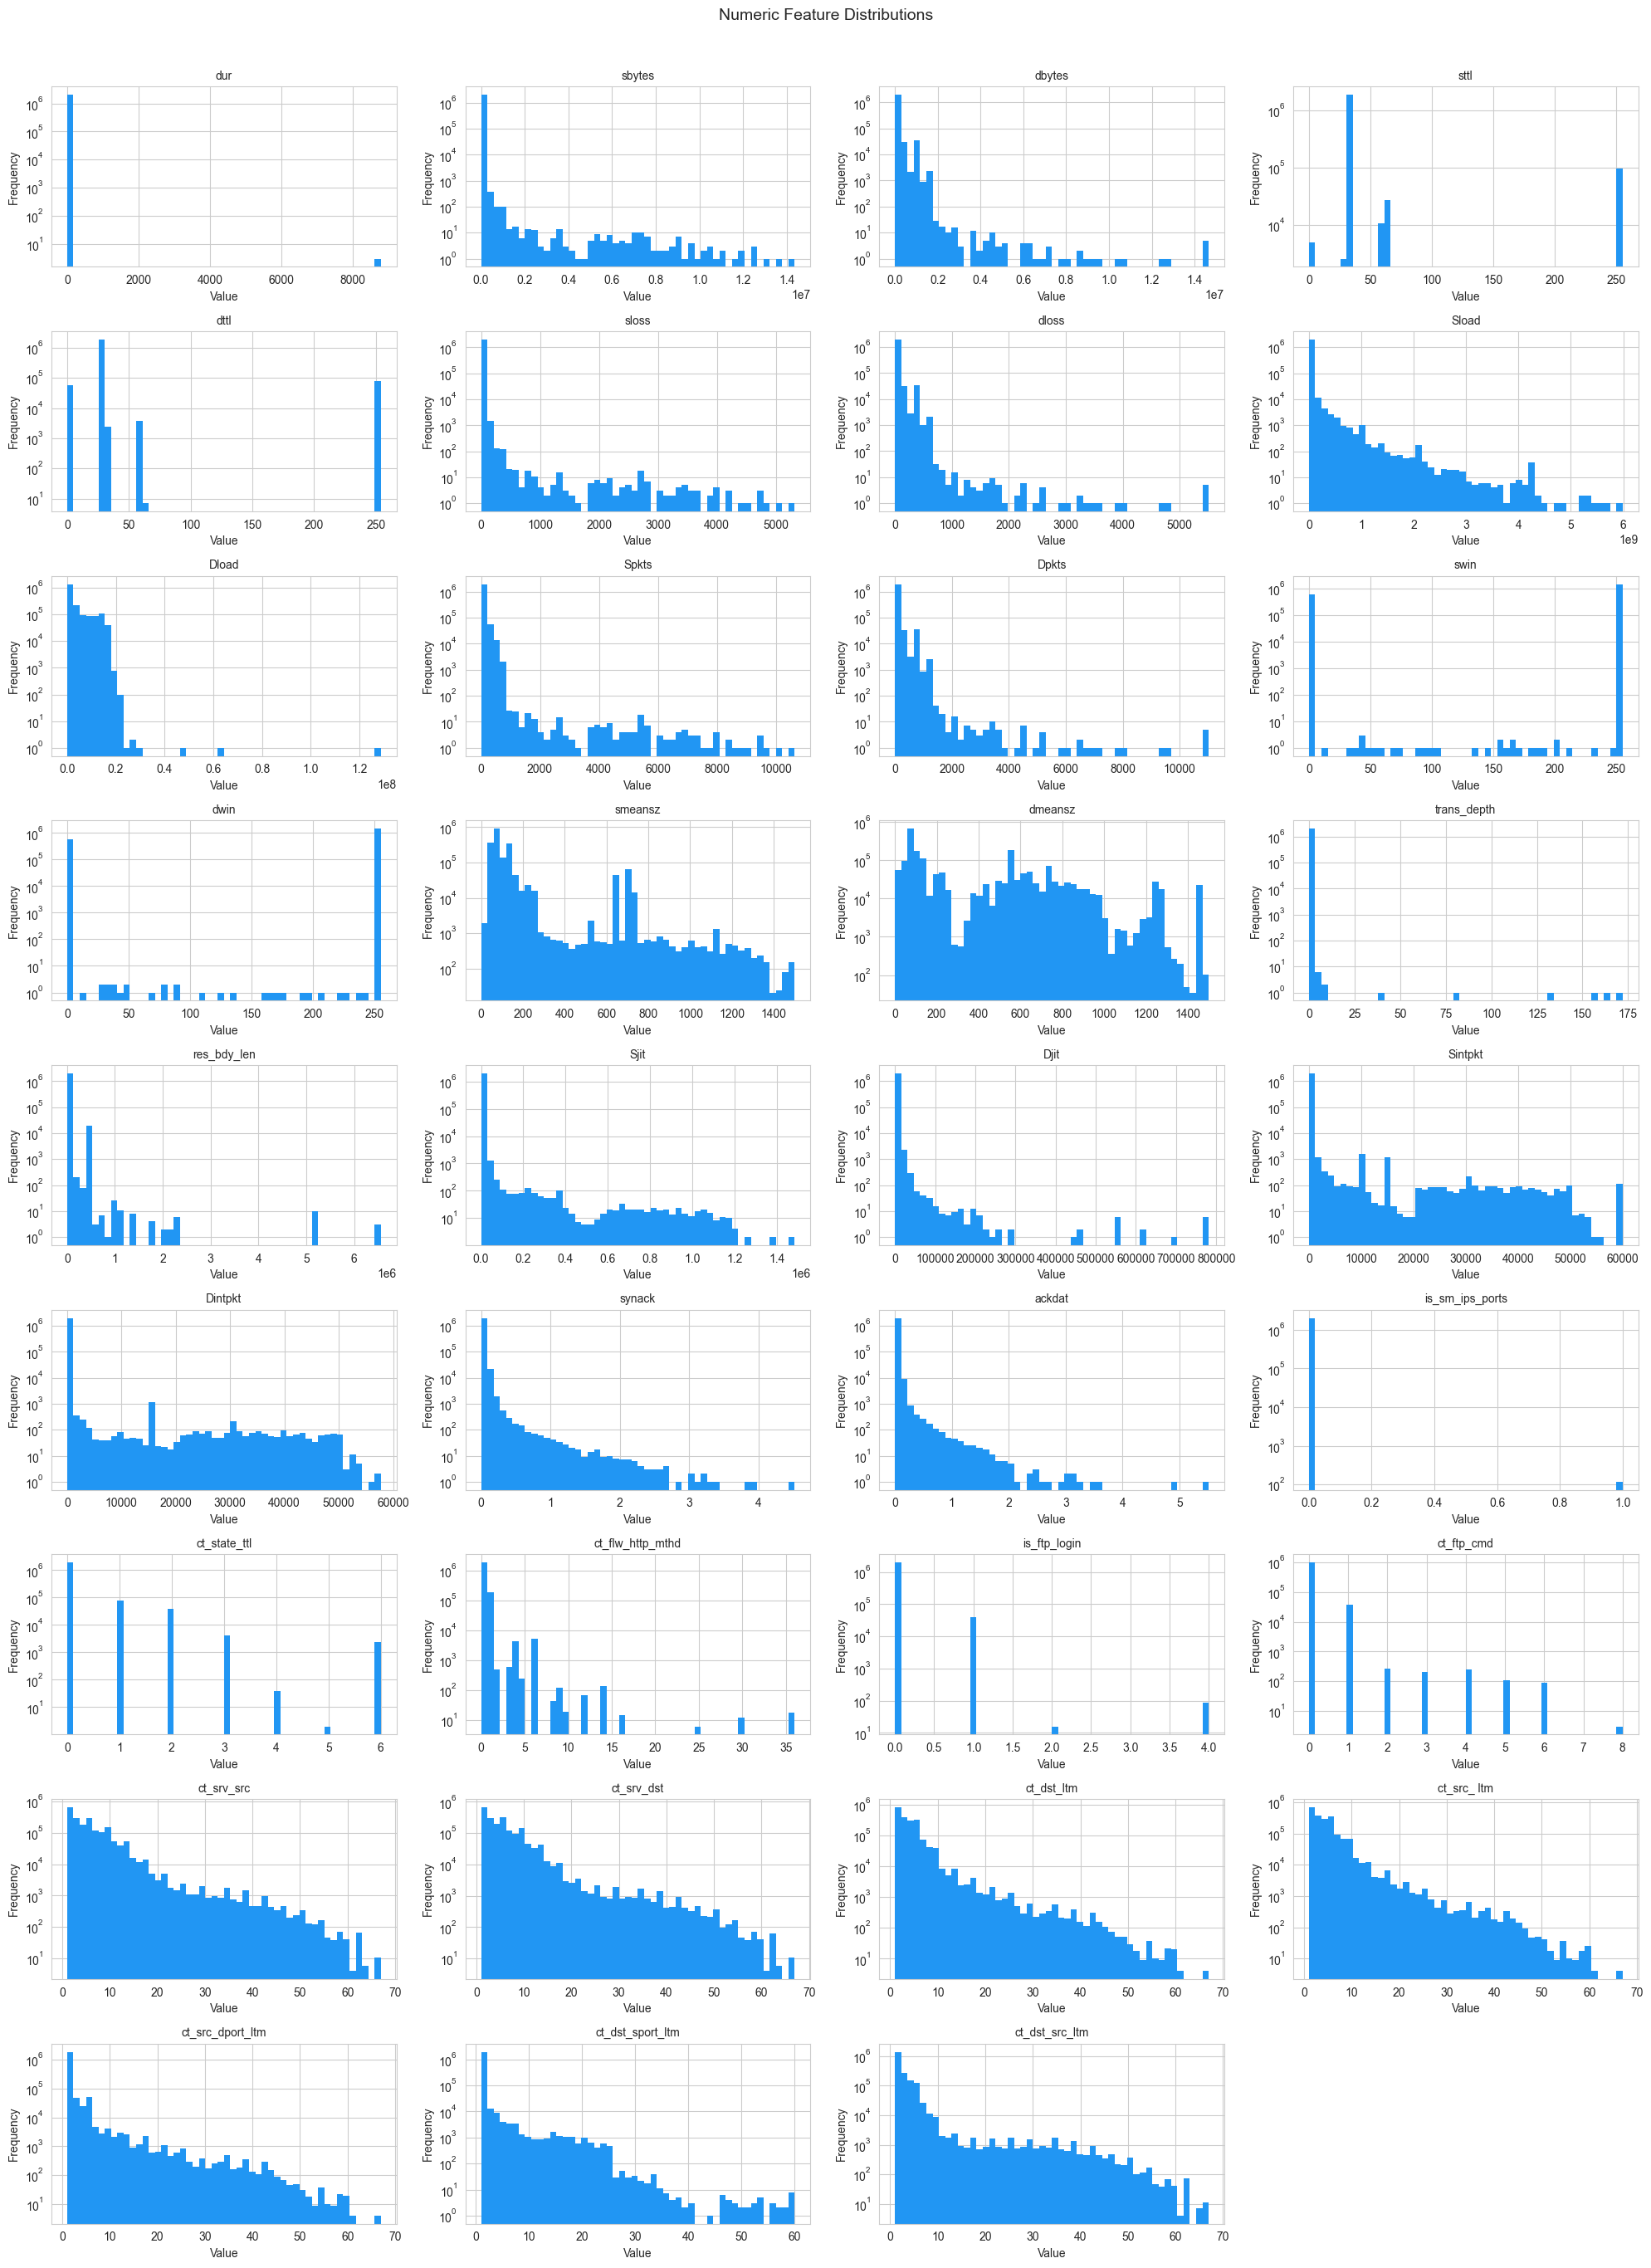

In [8]:
# Determine grid dimensions for the subplot layout
number_of_columns = 4
number_of_rows = int(np.ceil(len(numeric_columns) / number_of_columns))

fig, axes = plt.subplots(number_of_rows, number_of_columns, figsize=(20, number_of_rows * 3))
axes = axes.flatten()

# Plot a histogram for each numeric feature using a log y-axis to handle skewed distributions
for index, column in enumerate(numeric_columns):
    axes[index].hist(df[column].dropna(), bins=50, color='#2196F3', edgecolor='none')
    axes[index].set_title(column, fontsize=10)
    axes[index].set_xlabel('Value')
    axes[index].set_ylabel('Frequency')
    axes[index].set_yscale('log')

# Hide unused subplot axes
for index in range(len(numeric_columns), len(axes)):
    axes[index].set_visible(False)

fig.suptitle('Numeric Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4.6: Correlation Analysis

Correlation analysis measures the linear and monotonic relationships between features and the binary target label, as well as among features themselves. The Kendall tau coefficient is used throughout this notebook because it is rank-based and robust to the heavy outliers present in network traffic data — extreme values have minimal influence on rank ordering compared to Pearson's method. Features with a weak correlation to `Label` (|τ| < 0.05) are candidates for removal as low-signal predictors. Feature pairs with a strong mutual correlation (|τ| > 0.9) are likely redundant, and one member of each pair can be dropped without meaningful information loss. Final removal decisions are applied in notebook 05.

In [9]:
# Compute the Kendall tau correlation matrix for all numeric features including Label
correlation_matrix = df[numeric_columns + ['Label']].corr(method='kendall')

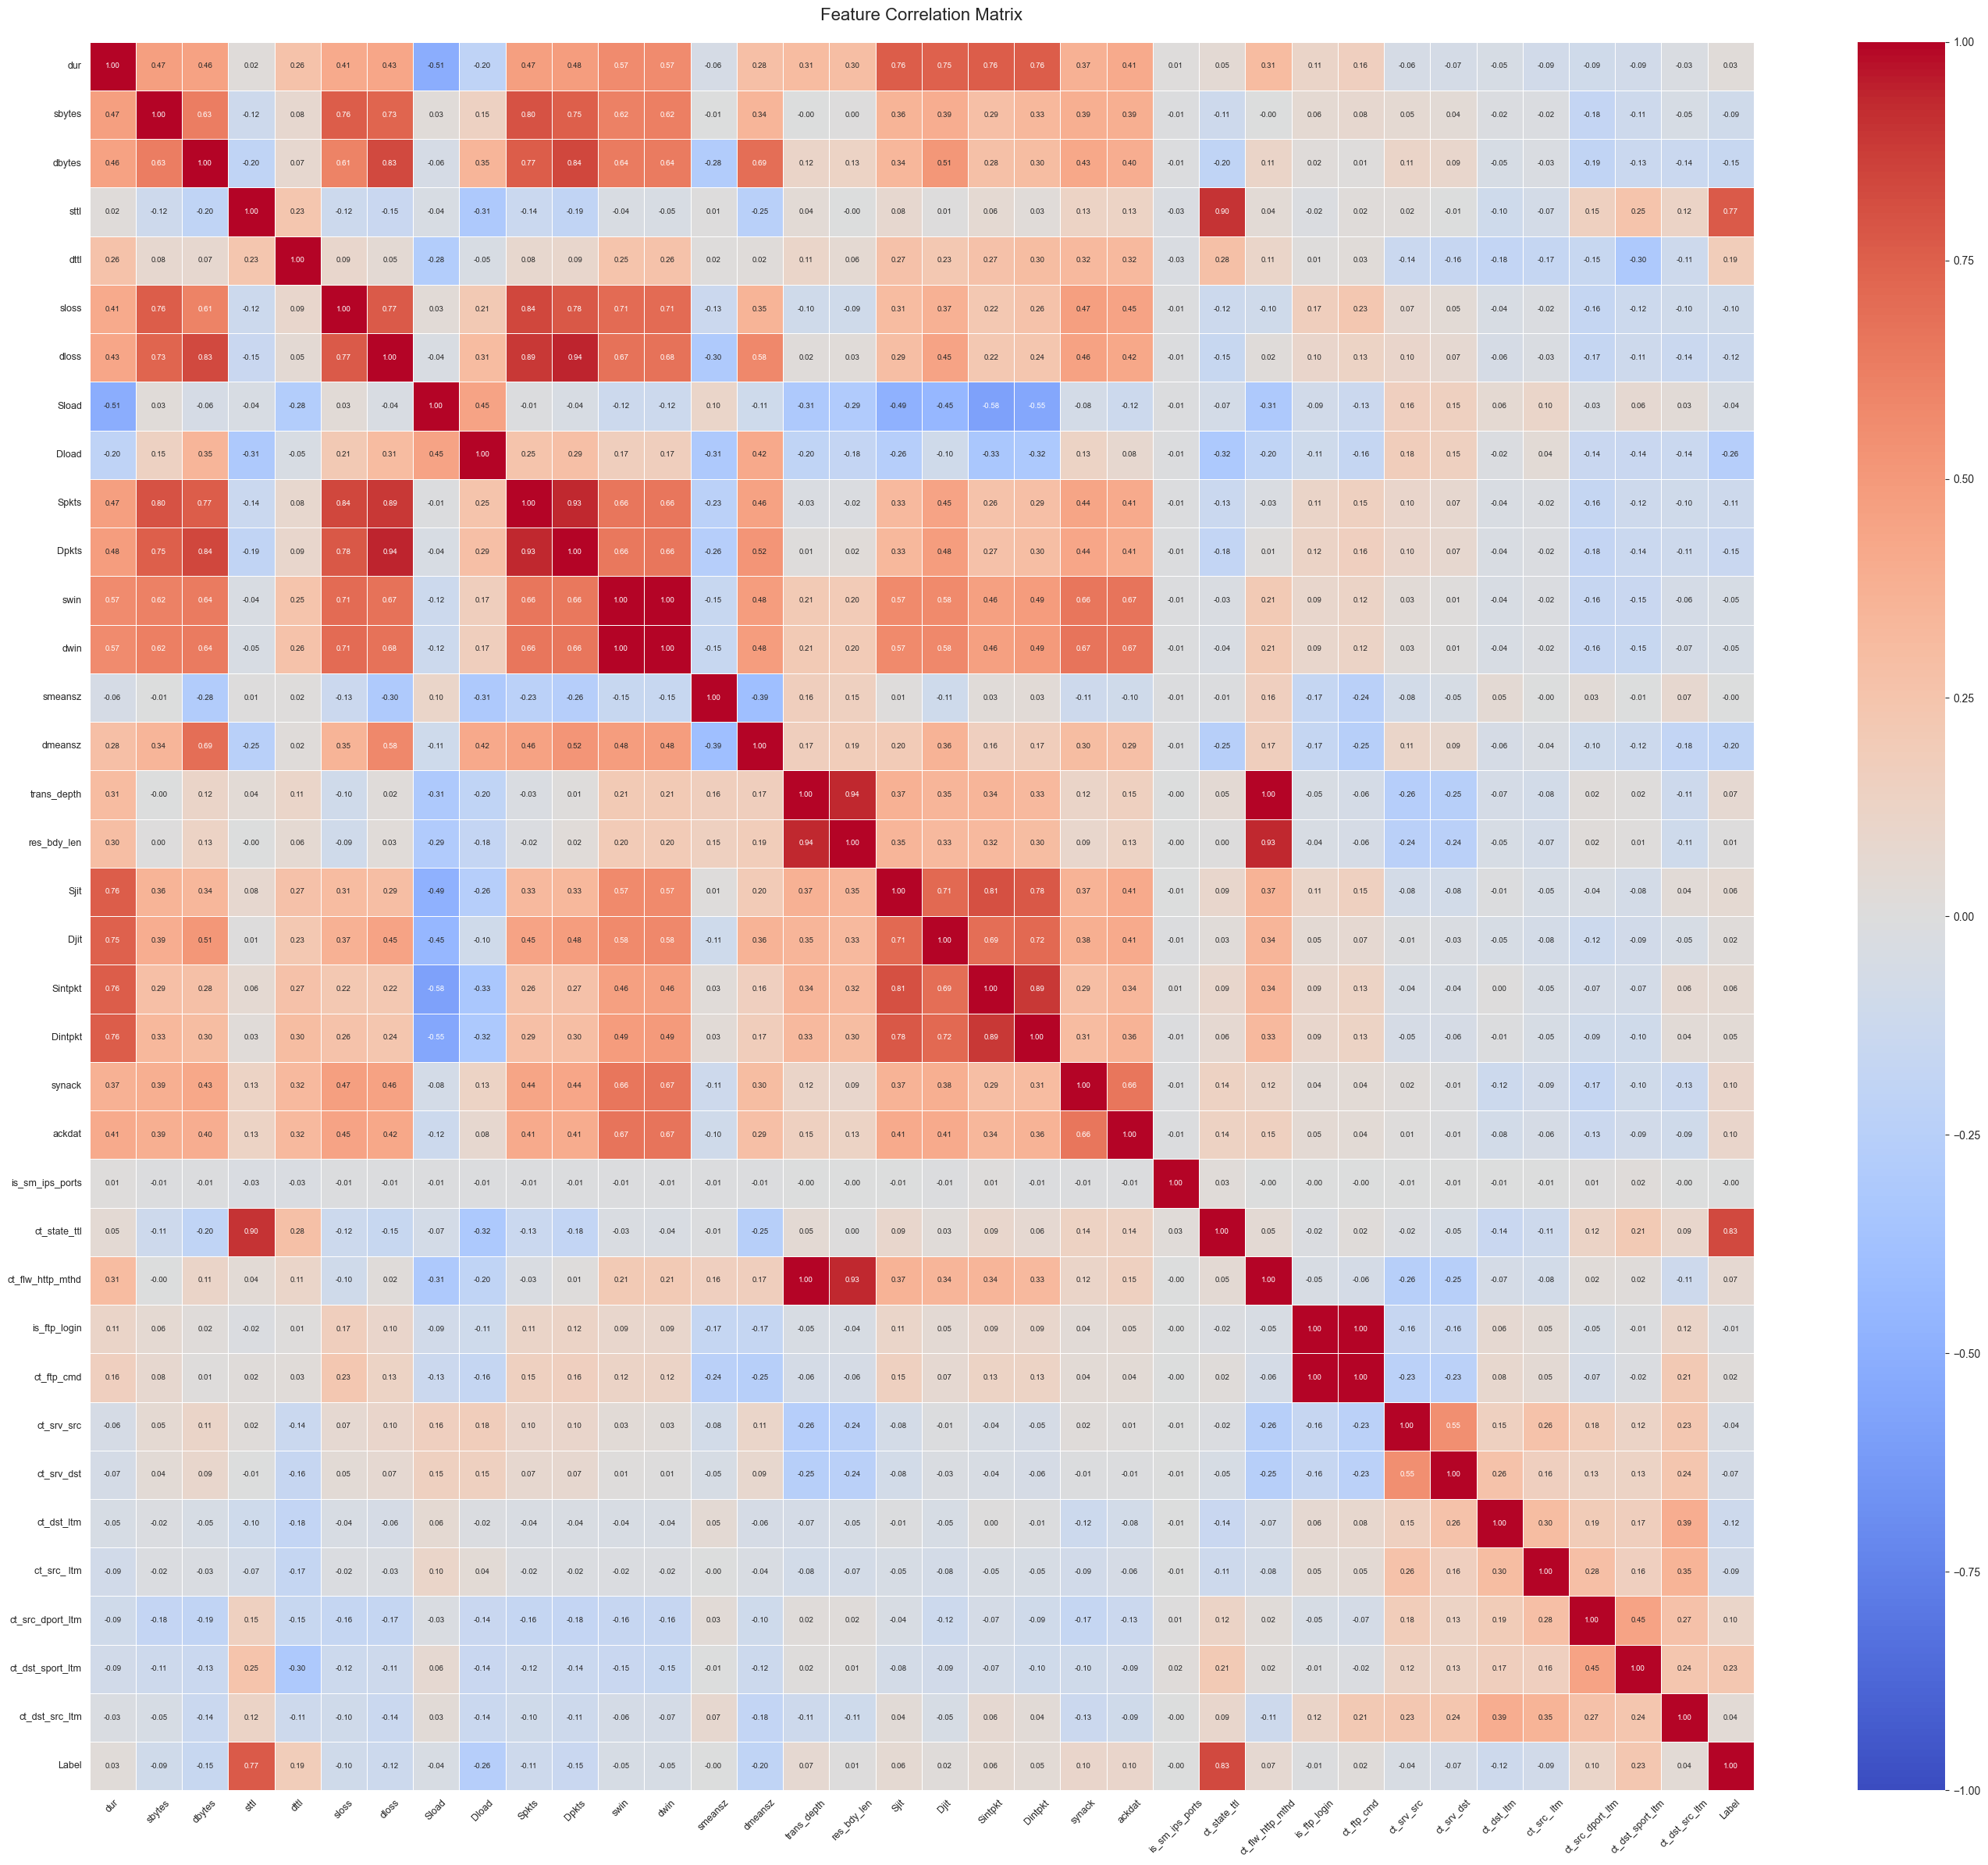

In [10]:
# Plot an annotated heatmap of the full correlation matrix
fig, ax = plt.subplots(figsize=(28, 24))

sns.heatmap(
    correlation_matrix,
    ax=ax,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
)
ax.set_title('Feature Correlation Matrix', fontsize=16, pad=20)
ax.tick_params(axis='x', labelsize=9, rotation=45)
ax.tick_params(axis='y', labelsize=9, rotation=0)

plt.tight_layout()
plt.show()

In [11]:
# Extract and display feature correlations with the Label column, sorted by absolute value
label_correlation = correlation_matrix['Label'].drop('Label').sort_values(key=abs, ascending=False)
print('Feature correlation with Label (Kendall tau, sorted by absolute value):')
print(label_correlation.to_string())

Feature correlation with Label (Kendall tau, sorted by absolute value):
ct_state_ttl        0.832630
sttl                0.768629
Dload              -0.259922
ct_dst_sport_ltm    0.232657
dmeansz            -0.196263
dttl                0.186524
dbytes             -0.154589
Dpkts              -0.147746
dloss              -0.118736
ct_dst_ltm         -0.116788
Spkts              -0.109914
ct_src_dport_ltm    0.102139
sloss              -0.100312
ackdat              0.097631
synack              0.096927
sbytes             -0.094296
ct_src_ ltm        -0.086993
trans_depth         0.065491
ct_srv_dst         -0.065327
ct_flw_http_mthd    0.065175
Sjit                0.059561
Sintpkt             0.058523
swin               -0.048319
dwin               -0.047695
Dintpkt             0.045918
ct_srv_src         -0.044877
ct_dst_src_ltm      0.042084
Sload              -0.040068
dur                 0.028056
ct_ftp_cmd          0.023046
Djit                0.021147
is_ftp_login       -0.011656


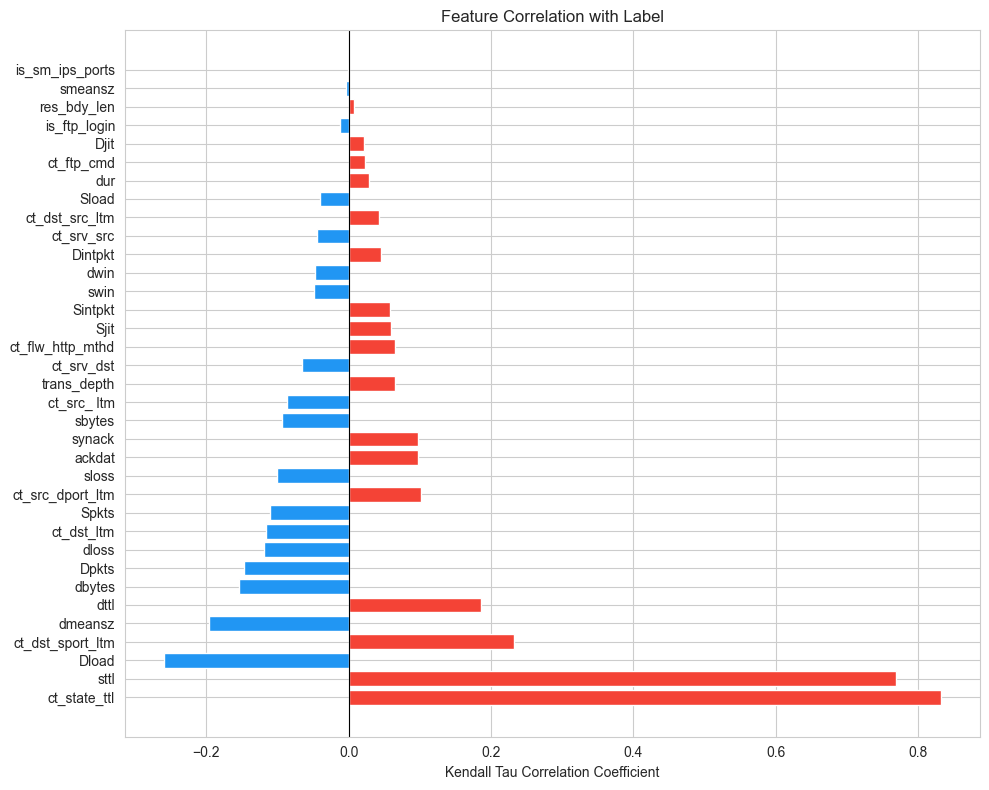

In [12]:
# Plot a bar chart of each feature's correlation with the Label column
fig, ax = plt.subplots(figsize=(10, 8))

colours = ['#F44336' if v >= 0 else '#2196F3' for v in label_correlation.values]
ax.barh(label_correlation.index, label_correlation.values, color=colours)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Label')
ax.set_xlabel('Kendall Tau Correlation Coefficient')

plt.tight_layout()
plt.show()

In [13]:
# Extract all correlation pairs from the upper triangle (excludes duplicate pairs and self-correlations)
full_upper = (
    correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
full_upper.columns = ['Feature A', 'Feature B', 'Correlation']

# Feature-to-label correlations: features with |τ| < 0.05 have weak predictive signal and are candidates
# for removal. The threshold is lower than the typical Pearson cutoff (~0.05–0.10) because Kendall tau
# values are inherently smaller in magnitude (~2/3 of Pearson). Final removal decisions belong in
# 05_feature_engineering.
LOW_CORRELATION_THRESHOLD = 0.05
feature_label_correlation = (
    full_upper[full_upper['Feature B'] == 'Label']
    .copy()
    .sort_values('Correlation', key=abs, ascending=True)
    .reset_index(drop=True)
)
low_correlation_features = feature_label_correlation[
    feature_label_correlation['Correlation'].abs() < LOW_CORRELATION_THRESHOLD
].reset_index(drop=True)
print(f'Features with |τ| < {LOW_CORRELATION_THRESHOLD} with Label (candidates for removal): {len(low_correlation_features)}')
display(low_correlation_features)

# Feature-to-feature correlations: pairs with |τ| > 0.9 are likely redundant and one of each pair
# could be dropped to reduce dimensionality
high_correlation_pairs = (
    full_upper[(full_upper['Correlation'].abs() > 0.9) & (full_upper['Feature B'] != 'Label')]
    .copy()
    .sort_values('Correlation', key=abs, ascending=False)
    .reset_index(drop=True)
)
print(f'\nFeature pairs with |τ| > 0.9 (candidates for removal): {len(high_correlation_pairs)}')
display(high_correlation_pairs)

Features with |τ| < 0.05 with Label (candidates for removal): 13


,Feature A,Feature B,Correlation
0,is_sm_ips_ports,Label,-0.001631
1,smeansz,Label,-0.004450
2,res_bdy_len,Label,0.007607
3,is_ftp_login,Label,-0.011656
4,Djit,Label,0.021147
5,ct_ftp_cmd,Label,0.023046
6,dur,Label,0.028056
7,Sload,Label,-0.040068
8,ct_dst_src_ltm,Label,0.042084
9,ct_srv_src,Label,-0.044877



Feature pairs with |τ| > 0.9 (candidates for removal): 8


,Feature A,Feature B,Correlation
0,is_ftp_login,ct_ftp_cmd,0.998450
1,trans_depth,ct_flw_http_mthd,0.997206
2,swin,dwin,0.997007
3,dloss,Dpkts,0.938239
4,trans_depth,res_bdy_len,0.935639
5,res_bdy_len,ct_flw_http_mthd,0.934625
6,Spkts,Dpkts,0.930827
7,sttl,ct_state_ttl,0.903368


## 4.7: Outlier Detection

Outlier detection identifies records with extreme values that deviate significantly from the bulk of the data. In network traffic, outliers can represent genuine attack behaviour — such as unusually high packet counts in a DoS attack — or data quality issues. Understanding which features carry the most outliers informs whether to cap, transform, or preserve those values during preprocessing. IQR-based bounds are used to flag outliers (values below Q1 − 1.5·IQR or above Q3 + 1.5·IQR), and the top outlier-prone features are visualised as box plots split by label to compare the outlier distribution between normal and attack records.

In [14]:
# Compute IQR bounds for each numeric feature
Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers per feature and express as a percentage of total records
outlier_counts = ((df[numeric_columns] < lower_bound) | (df[numeric_columns] > upper_bound)).sum()
outlier_percentage = (outlier_counts / len(df) * 100).round(2)

# Summarise and sort by outlier count descending
outlier_summary = pd.DataFrame({
    'Outlier Count': outlier_counts,
    'Outlier %': outlier_percentage
}).sort_values('Outlier Count', ascending=False)

display(outlier_summary)

,Outlier Count,Outlier %
Djit,361708,17.87
ct_src_dport_ltm,357934,17.68
Sjit,349817,17.28
dur,340130,16.80
Sintpkt,338730,16.73
Dintpkt,336865,16.64
Dload,265389,13.11
sbytes,227094,11.22
dbytes,202598,10.01
trans_depth,198994,9.83


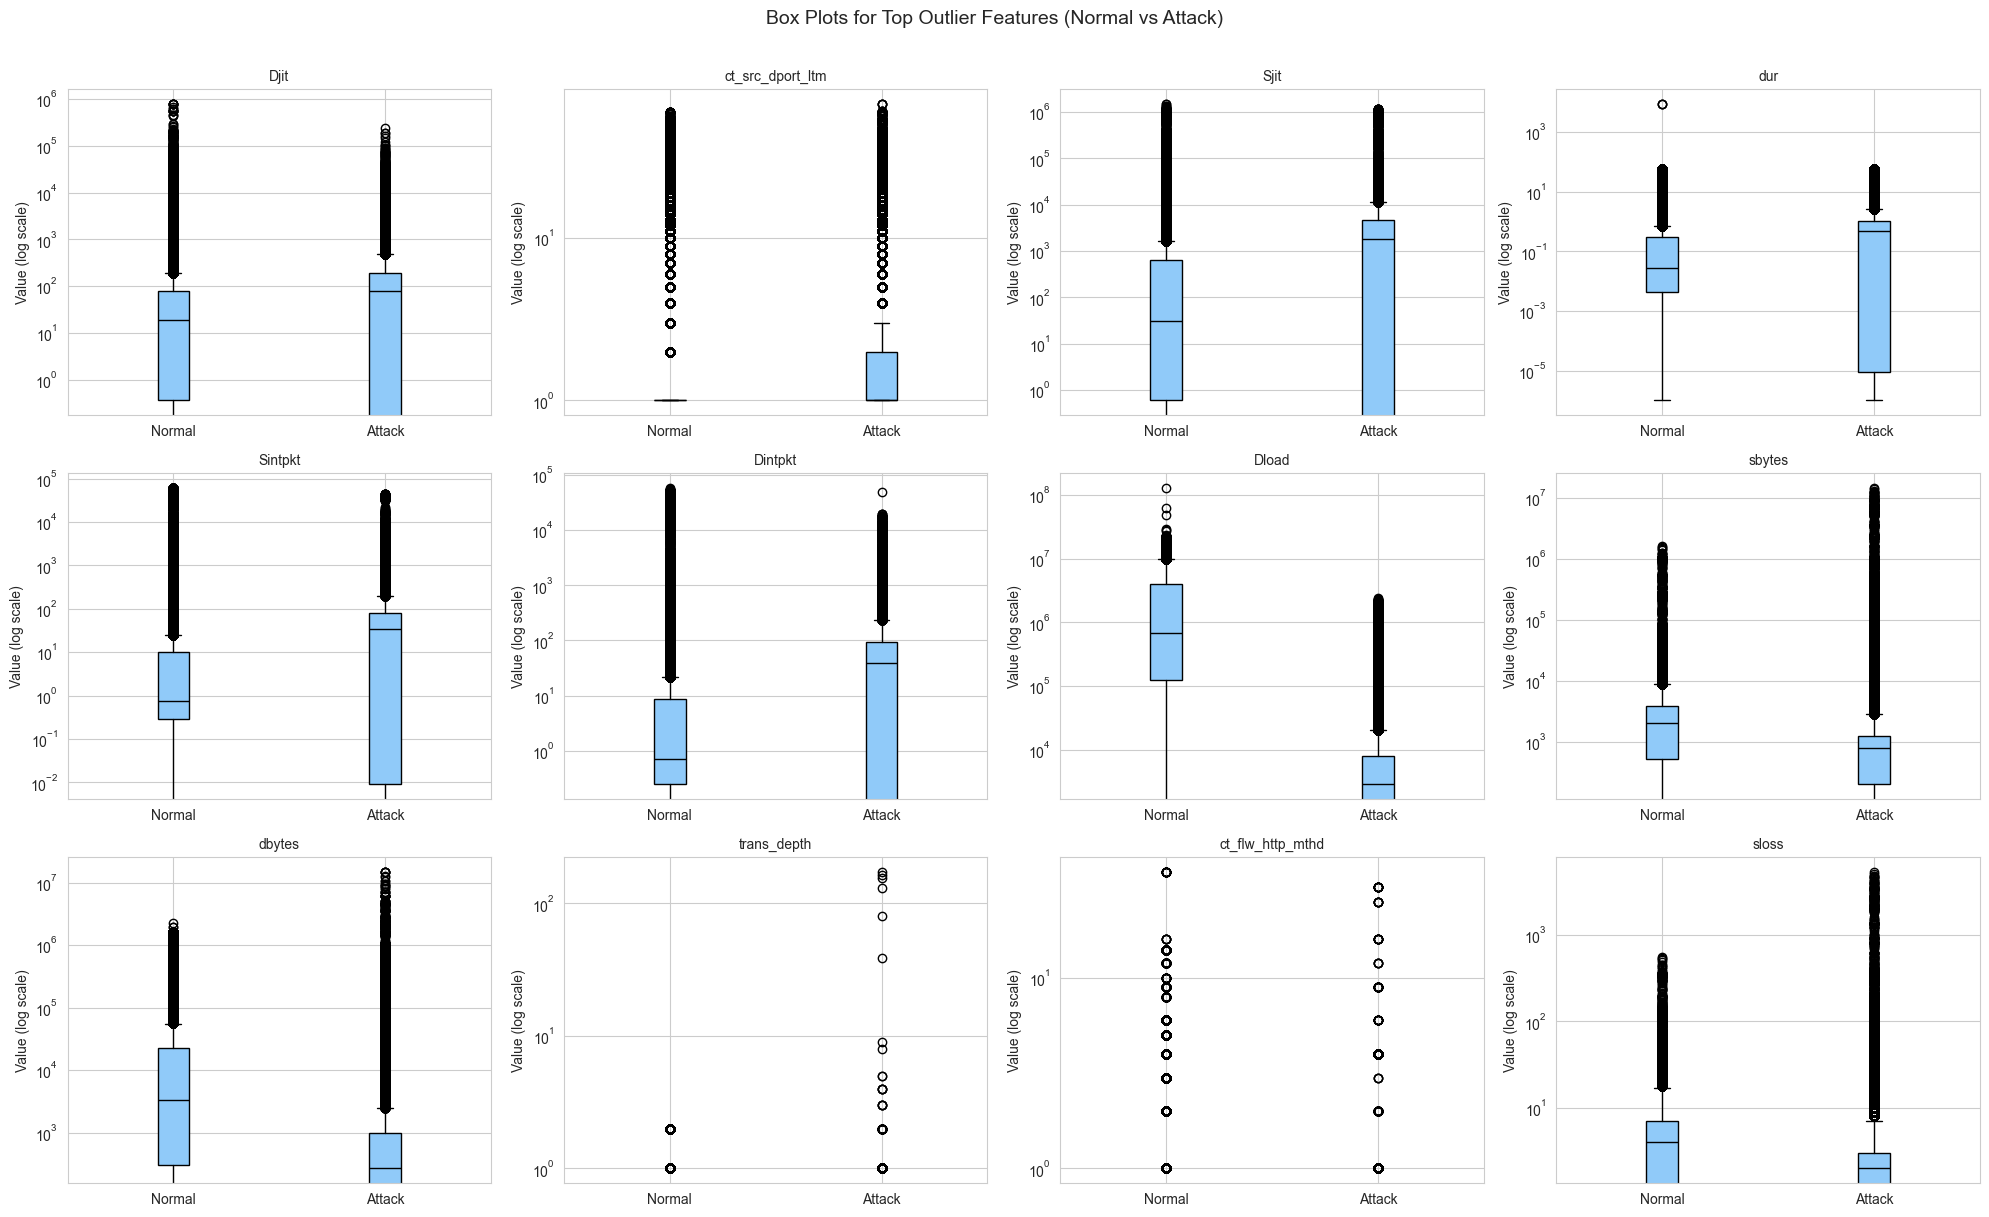

In [15]:
# Select the top 12 features with the most outliers
top_outlier_features = outlier_summary.head(12).index.tolist()

# Determine grid dimensions for the subplot layout
number_of_columns = 4
number_of_rows = int(np.ceil(len(top_outlier_features) / number_of_columns))

fig, axes = plt.subplots(number_of_rows, number_of_columns, figsize=(20, number_of_rows * 4))
axes = axes.flatten()

# Box plot per feature split by label to compare outlier spread between normal and attack traffic
# Log scale on y-axis keeps the box and whiskers visible despite extreme outliers
for index, column in enumerate(top_outlier_features):
    normal_data = df[df['Label'] == 0][column].dropna()
    attack_data = df[df['Label'] == 1][column].dropna()

    axes[index].boxplot(
        [normal_data, attack_data],
        tick_labels=['Normal', 'Attack'],
        patch_artist=True,
        boxprops=dict(facecolor='#90CAF9'),
        medianprops=dict(color='black')
    )
    axes[index].set_title(column, fontsize=10)
    axes[index].set_ylabel('Value (log scale)')
    axes[index].set_yscale('log')

# Remove unused subplot axes from the figure
for index in range(len(top_outlier_features), len(axes)):
    fig.delaxes(axes[index])

fig.suptitle('Box Plots for Top Outlier Features (Normal vs Attack)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()